# 2. Perceptron — experimento reproduzível

Este notebook gera os dados, treina um perceptron escrito à mão e salva as Figuras 1–6 em `../figures/`. A execução é reproduzível; execute as células na ordem.

A única RNG é `rng = np.random.default_rng(42)`. A ordem de sorteio fixa é: dados do Exercício 1, `w0` do Exercício 1, dados do Exercício 2, `w0` do Exercício 2. Não embaralhar nem introduzir sorteios entre essas etapas.

In [1]:
# Imports permitidos, resolução dos arquivos locais e única semente do experimento.
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'perceptron.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'docs' / 'exercises' / 'perceptron' / 'code'
FIGURES_DIR = NOTEBOOK_DIR.parent / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(NOTEBOOK_DIR))
from perceptron import accuracy, make_data, predict, train_perceptron

rng = np.random.default_rng(42)
plt.rcParams.update({'figure.figsize': (8, 6), 'axes.grid': True, 'grid.alpha': 0.2})
print(f'NumPy {np.__version__}; pandas {pd.__version__}; figuras: {FIGURES_DIR.resolve()}')

NumPy 2.5.3; pandas 3.0.5; figuras: /Users/laurapontiroli/Desktop/DeepLearning-CLASS/docs/exercises/perceptron/figures


## Exercise 1 — A: geração dos dados e Figura 1

Gero 1.000 pontos por classe com covariância $0.5I$. `make_data` empilha classe 0 antes da classe 1, sem embaralhar. A inicialização sorteada depois dos dados será reutilizada nas duas taxas de aprendizagem.

In [2]:
# Ordem fixa dos sorteios: dados Ex. 1, w0 Ex. 1, dados Ex. 2, w0 Ex. 2.
X1, y1 = make_data(rng, [1.5, 1.5], [5.0, 5.0], variance=0.5, samples_per_class=1000)
w0_ex1 = rng.normal(0.0, 0.01, size=2)
b0_ex1 = 0.0
X2, y2 = make_data(rng, [3.0, 3.0], [4.0, 4.0], variance=1.5, samples_per_class=1000)
w0_ex2 = rng.normal(0.0, 0.01, size=2)
b0_ex2 = 0.0

assert X1.shape == X2.shape == (2000, 2)
assert y1.shape == y2.shape == (2000,)
assert np.all(y1[:1000] == 0) and np.all(y1[1000:] == 1)
assert np.all(y2[:1000] == 0) and np.all(y2[1000:] == 1)
print(f'w0 Ex. 1={w0_ex1}; w0 Ex. 2={w0_ex2}; b0=0 em ambos')

w0 Ex. 1=[0.00253205 0.00895218]; w0 Ex. 2=[ 0.01215829 -0.00450957]; b0=0 em ambos


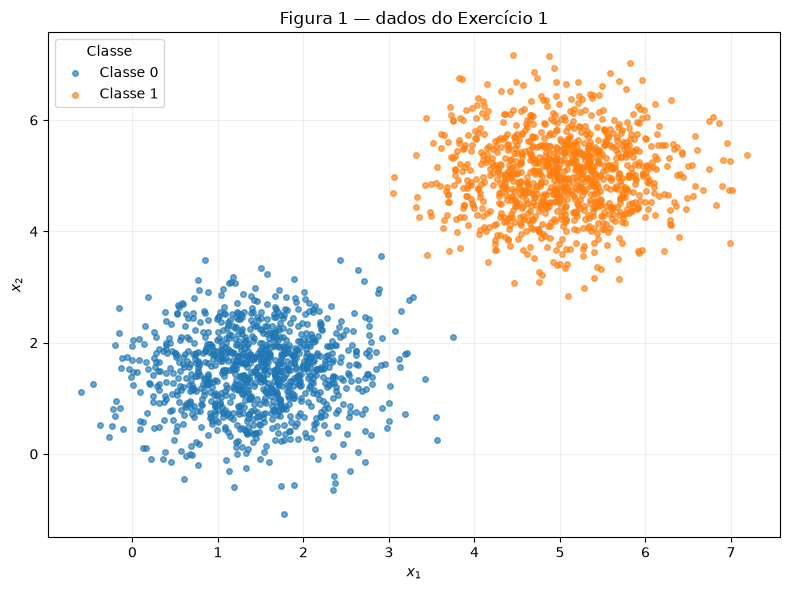

In [3]:
# Figura 1: nuvens de todas as observações do Exercício 1.
fig, ax = plt.subplots()
ax.scatter(X1[y1 == 0, 0], X1[y1 == 0, 1], s=16, alpha=0.65, label='Classe 0')
ax.scatter(X1[y1 == 1, 0], X1[y1 == 1, 1], s=16, alpha=0.65, label='Classe 1')
ax.set(title='Figura 1 — dados do Exercício 1', xlabel='$x_1$', ylabel='$x_2$')
ax.legend(title='Classe')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig1.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

## Exercise 1 — B: implementação; C: treinamento e Figuras 2–3

A implementação manual comentada está em `perceptron.py`. Usa a previsão binária indicada no enunciado e a atualização $e=y-\hat y$, percorre os dados na ordem fixa e para após uma época sem atualizações ou após 100 épocas. As duas execuções usam cópias do mesmo `w0`; somente $\eta$ muda.

In [4]:
run_ex1_eta_001 = train_perceptron(X1, y1, w0_ex1.copy(), b0_ex1, learning_rate=0.01, max_epochs=100)
run_ex1_eta_1 = train_perceptron(X1, y1, w0_ex1.copy(), b0_ex1, learning_rate=1.0, max_epochs=100)

def describe_run(name, result):
    direction = result.weights / np.linalg.norm(result.weights)
    print(f'{name}: w={result.weights}; b={result.bias:.12g}; ||w||={np.linalg.norm(result.weights):.12g}')
    print(f'  w/||w||={direction}; épocas={result.epochs}; acurácia final={result.accuracy_history[-1]:.6%}')
    print(f'  atualizações por época={result.updates_per_epoch}')

describe_run('Ex. 1, eta=0.01', run_ex1_eta_001)
describe_run('Ex. 1, eta=1.0', run_ex1_eta_1)

Ex. 1, eta=0.01: w=[0.05049707 0.02887168]; b=-0.25; ||w||=0.0581681025169
  w/||w||=[0.86812305 0.49634905]; épocas=26; acurácia final=100.000000%
  atualizações por época=[3, 3, 4, 4, 3, 4, 3, 4, 2, 4, 2, 4, 2, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 1, 0]
Ex. 1, eta=1.0: w=[5.87061596 3.3592393 ]; b=-31; ||w||=6.76377265151
  w/||w||=[0.86794992 0.49665172]; épocas=37; acurácia final=100.000000%
  atualizações por época=[2, 4, 3, 3, 4, 3, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 3, 3, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 2, 3, 1, 0]


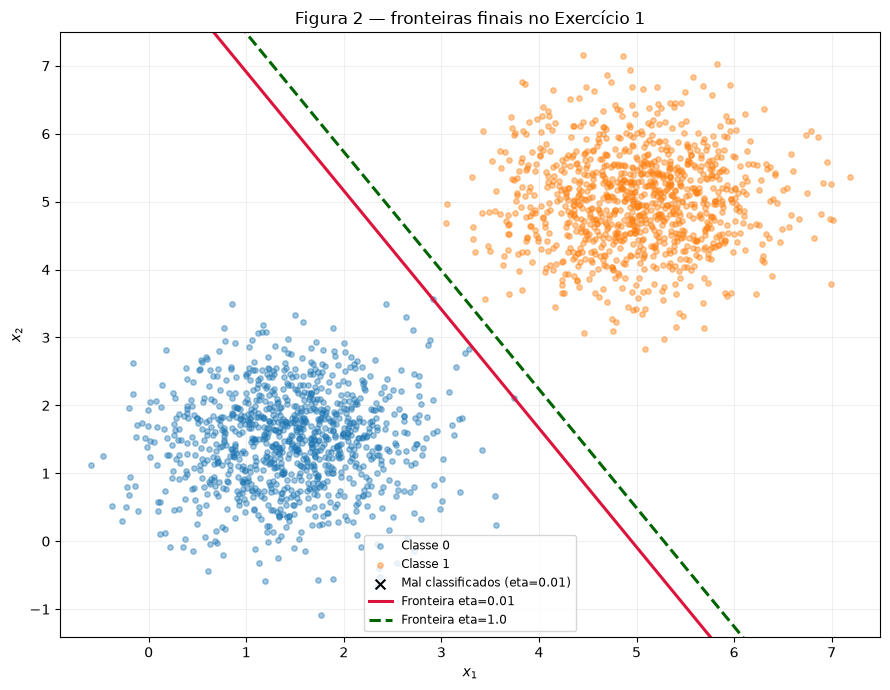

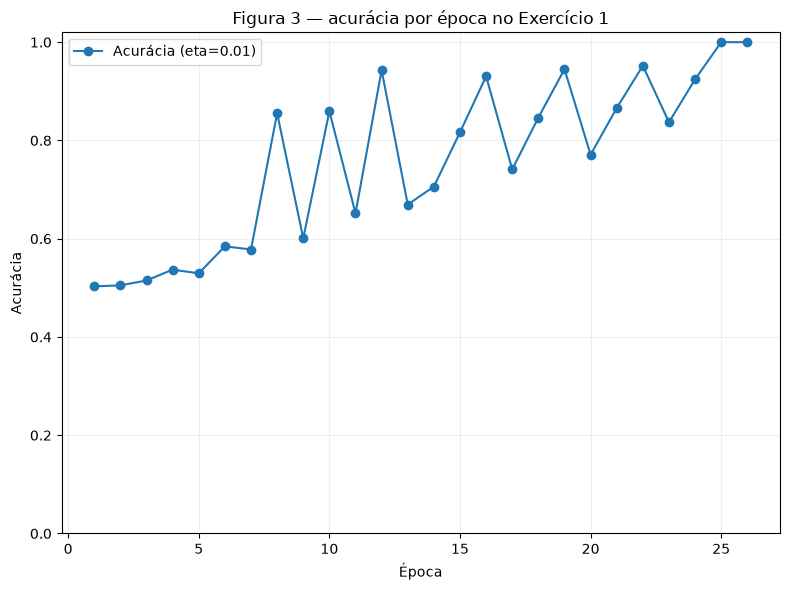

In [5]:
def draw_boundary(ax, features, weights, bias, label, color, linestyle='-'):
    # Usa reta explícita quando w2 é seguro; caso contrário desenha a vertical.
    x_min, x_max = float(features[:, 0].min()), float(features[:, 0].max())
    y_min, y_max = float(features[:, 1].min()), float(features[:, 1].max())
    x_margin, y_margin = 0.04 * (x_max - x_min), 0.04 * (y_max - y_min)
    if abs(weights[1]) > 1e-12:
        x_line = np.linspace(x_min - x_margin, x_max + x_margin, 300)
        y_line = -(weights[0] * x_line + bias) / weights[1]
        ax.plot(x_line, y_line, color=color, linestyle=linestyle, linewidth=2.2, label=label)
    elif abs(weights[0]) > 1e-12:
        ax.axvline(-bias / weights[0], color=color, linestyle=linestyle, linewidth=2.2, label=label)
    else:
        raise ValueError('Fronteira indefinida para w=[0, 0].')
    ax.set_xlim(x_min - x_margin, x_max + x_margin)
    ax.set_ylim(y_min - y_margin, y_max + y_margin)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X1[y1 == 0, 0], X1[y1 == 0, 1], s=15, alpha=0.42, label='Classe 0')
ax.scatter(X1[y1 == 1, 0], X1[y1 == 1, 1], s=15, alpha=0.42, label='Classe 1')
wrong1 = predict(X1, run_ex1_eta_001.weights, run_ex1_eta_001.bias) != y1
ax.scatter(X1[wrong1, 0], X1[wrong1, 1], marker='x', color='black', s=50, label='Mal classificados (eta=0.01)')
draw_boundary(ax, X1, run_ex1_eta_001.weights, run_ex1_eta_001.bias, 'Fronteira eta=0.01', 'crimson')
draw_boundary(ax, X1, run_ex1_eta_1.weights, run_ex1_eta_1.bias, 'Fronteira eta=1.0', 'darkgreen', '--')
ax.set(title='Figura 2 — fronteiras finais no Exercício 1', xlabel='$x_1$', ylabel='$x_2$')
ax.legend(loc='best', fontsize='small')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig2.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots()
ax.plot(np.arange(1, run_ex1_eta_001.epochs + 1), run_ex1_eta_001.accuracy_history, marker='o', label='Acurácia (eta=0.01)')
ax.set(title='Figura 3 — acurácia por época no Exercício 1', xlabel='Época', ylabel='Acurácia')
ax.set_ylim(0.0, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

### Exercise 1 — D: análise e prova para início zero

Os erros não nulos são os únicos que atualizam os parâmetros. Use a lista de atualizações por época impressa acima para justificar a parada. Compare taxas apenas com os números obtidos: direções $w/\|w\|$, bias, normas, épocas e acurácias.

Se $w_0=b_0=0$, as trajetórias para uma taxa $\eta>0$ satisfazem $(w_t(\eta),b_t(\eta))=\eta(w_t(1),b_t(1))$. A base é imediata. Na hipótese indutiva, a margem é multiplicada por um escalar positivo, preservando previsão e erro. Portanto $w_{t+1}(\eta)=\eta w_t(1)+\eta e x=\eta(w_t(1)+e x)=\eta w_{t+1}(1)$, e o mesmo vale para $b$. Logo $w(\eta_2)=(\eta_2/\eta_1)w(\eta_1)$; as fronteiras, erros e épocas são iguais. Com inicialização geral, $(w,b)(\eta;w_0)=\eta(w,b)(1;w_0/\eta)$.

## Exercise 2 — A: geração dos dados e Figura 4

O conjunto tem 1.000 pontos por classe, médias [3, 3] e [4, 4] e covariância $1.5I$. Os sorteios e os rótulos preservam classe 0 primeiro, sem embaralhamento.

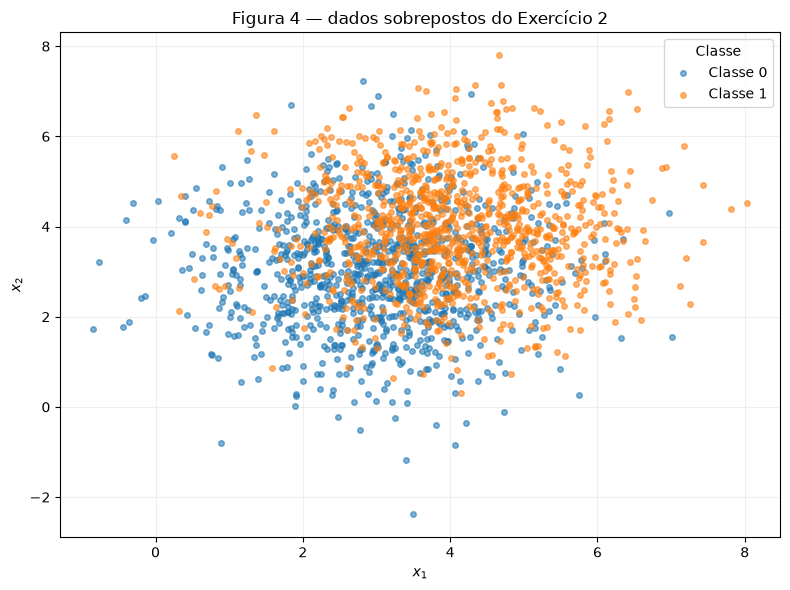

In [6]:
fig, ax = plt.subplots()
ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], s=16, alpha=0.58, label='Classe 0')
ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], s=16, alpha=0.58, label='Classe 1')
ax.set(title='Figura 4 — dados sobrepostos do Exercício 2', xlabel='$x_1$', ylabel='$x_2$')
ax.legend(title='Classe')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

## Exercise 2 — B: treinamento com pocket; C: Figuras 5–6

Reutilizo a função sem alterações, apenas com `use_pocket=True`. Depois de cada atualização, a acurácia do conjunto completo é medida; se estritamente maior, cópias de $w,b$ e a época são guardadas. A curva pocket contém o melhor valor ao final de cada época.

Ex. 2, pesos finais: w=[0.05448404 0.0480433 ]; b=-0.07; ||w||=0.072640683616
  w/||w||=[0.75004849 0.66138284]; épocas=100; acurácia final=50.150000%
  atualizações por época=[5, 2, 3, 2, 3, 2, 2, 4, 2, 3, 2, 3, 2, 3, 2, 2, 4, 2, 4, 2, 2, 4, 2, 3, 2, 2, 4, 2, 5, 4, 2, 4, 2, 5, 4, 2, 2, 4, 3, 2, 2, 5, 4, 2, 2, 4, 2, 3, 2, 2, 4, 2, 4, 2, 4, 2, 3, 2, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 2, 5, 4, 2, 2, 4, 2, 4, 3, 2, 2, 4, 2, 5, 4, 2, 3, 2, 3, 2, 4, 2, 4, 2, 4, 2, 3, 4, 2]
Acurácia dos pesos finais: 50.150000%
Pocket: w=[0.01066397 0.00872652]; b=-0.07; acurácia=71.100000%; época=86
Melhor acurácia ao final de cada época: [0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.526, 0.5465, 0.5465, 0.584, 0.584, 0.584, 0.584, 0.584, 0.584, 0.584, 0.584, 0.597, 0.597, 0.597, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.697, 0.69

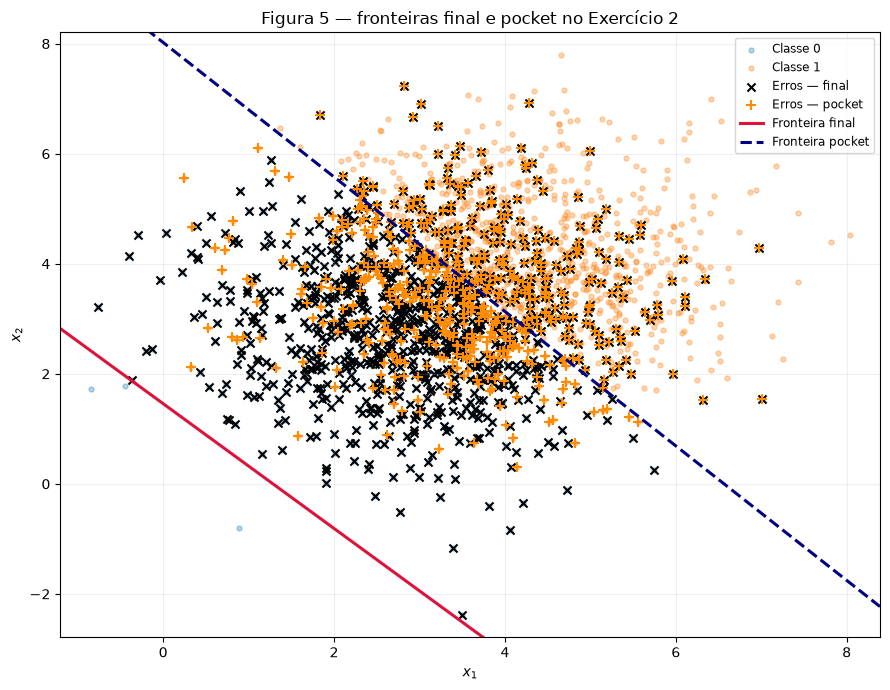

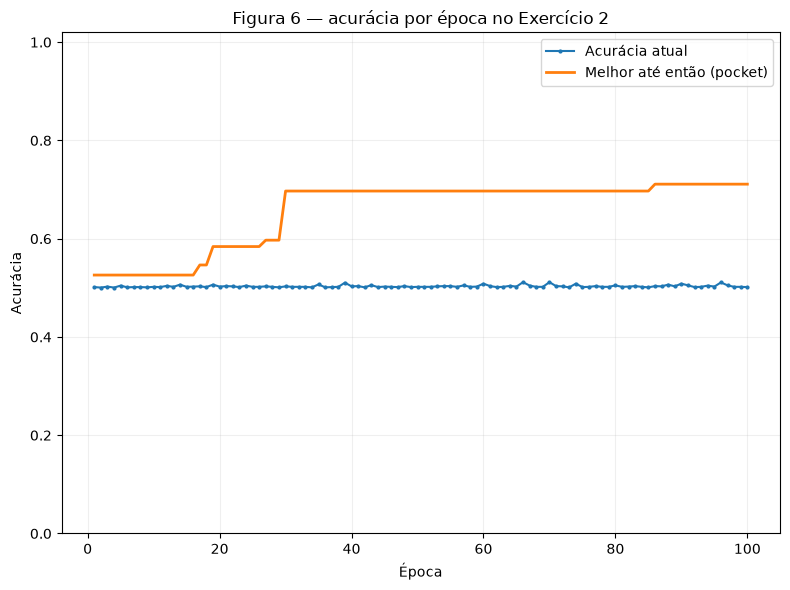

In [7]:
run_ex2 = train_perceptron(X2, y2, w0_ex2.copy(), b0_ex2, learning_rate=0.01, max_epochs=100, use_pocket=True)
final_ex2_accuracy = accuracy(X2, y2, run_ex2.weights, run_ex2.bias)
pocket_ex2_accuracy = accuracy(X2, y2, run_ex2.pocket_weights, run_ex2.pocket_bias)
describe_run('Ex. 2, pesos finais', run_ex2)
print(f'Acurácia dos pesos finais: {final_ex2_accuracy:.6%}')
print(f'Pocket: w={run_ex2.pocket_weights}; b={run_ex2.pocket_bias:.12g}; acurácia={pocket_ex2_accuracy:.6%}; época={run_ex2.pocket_epoch}')
print(f'Melhor acurácia ao final de cada época: {run_ex2.pocket_accuracy_history}')

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], s=13, alpha=0.32, label='Classe 0')
ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], s=13, alpha=0.32, label='Classe 1')
wrong_final = predict(X2, run_ex2.weights, run_ex2.bias) != y2
wrong_pocket = predict(X2, run_ex2.pocket_weights, run_ex2.pocket_bias) != y2
ax.scatter(X2[wrong_final, 0], X2[wrong_final, 1], marker='x', color='black', s=34, label='Erros — final')
ax.scatter(X2[wrong_pocket, 0], X2[wrong_pocket, 1], marker='+', color='darkorange', s=42, label='Erros — pocket')
draw_boundary(ax, X2, run_ex2.weights, run_ex2.bias, 'Fronteira final', 'crimson')
draw_boundary(ax, X2, run_ex2.pocket_weights, run_ex2.pocket_bias, 'Fronteira pocket', 'navy', '--')
ax.set(title='Figura 5 — fronteiras final e pocket no Exercício 2', xlabel='$x_1$', ylabel='$x_2$')
ax.legend(loc='best', fontsize='small')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig5.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots()
epochs2 = np.arange(1, run_ex2.epochs + 1)
ax.plot(epochs2, run_ex2.accuracy_history, marker='.', markersize=4, label='Acurácia atual')
ax.plot(epochs2, run_ex2.pocket_accuracy_history, linewidth=2, label='Melhor até então (pocket)')
ax.set(title='Figura 6 — acurácia por época no Exercício 2', xlabel='Época', ylabel='Acurácia')
ax.set_ylim(0.0, 1.02)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6.png', dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

### Exercise 2 — D: análise

Compare acurácia final e pocket e descreva a posição da fronteira final observada na Figura 5. Cada erro altera $w$ em $\eta e x$ e o bias em $\eta e$; portanto, a fronteira pode oscilar e o último iterado depender do último erro. No conjunto separável do Exercício 1, a acurácia estabiliza; o teorema de convergência requer separabilidade linear (e dados limitados), hipótese que a sobreposição do Exercício 2 não satisfaz. Mais épocas podem apenas continuar os erros, e uma taxa menor altera a escala dos passos, mas não cria um separador nem garante convergência.

## Results summary

Tabela gerada diretamente dos objetos calculados acima. Todos os valores vêm da execução atual do notebook.

In [8]:
assert len(run_ex1_eta_001.updates_per_epoch) == run_ex1_eta_001.epochs
assert len(run_ex2.pocket_accuracy_history) == run_ex2.epochs
assert all((FIGURES_DIR / f'fig{i}.png').exists() for i in range(1, 7))
summary = pd.DataFrame([
    (1, 'Ex. 1: pesos finais w e bias b', f'w={run_ex1_eta_001.weights.tolist()}, b={run_ex1_eta_001.bias:.12g}'),
    (2, 'Ex. 1: épocas até convergência', str(run_ex1_eta_001.epochs)),
    (3, 'Ex. 1: acurácia final (eta=0.01)', f'{run_ex1_eta_001.accuracy_history[-1]:.6%}'),
    (4, 'Ex. 1: épocas e acurácia final (eta=1.0)', f'{run_ex1_eta_1.epochs}; {run_ex1_eta_1.accuracy_history[-1]:.6%}'),
    (5, 'Ex. 2: pesos finais w e bias b', f'w={run_ex2.weights.tolist()}, b={run_ex2.bias:.12g}'),
    (6, 'Ex. 2: acurácia dos pesos finais', f'{final_ex2_accuracy:.6%}'),
    (7, 'Ex. 2: acurácia dos pesos pocket', f'{pocket_ex2_accuracy:.6%}'),
    (8, 'Ex. 2: época do melhor pocket', str(run_ex2.pocket_epoch)),
], columns=['#', 'Métrica', 'Valor'])
summary

,#,Métrica,Valor
0,1,Ex. 1: pesos finais w e bias b,"w=[0.05049707037478693, 0.028871682215970675],..."
1,2,Ex. 1: épocas até convergência,26
2,3,Ex. 1: acurácia final (eta=0.01),100.000000%
3,4,Ex. 1: épocas e acurácia final (eta=1.0),37; 100.000000%
4,5,Ex. 2: pesos finais w e bias b,"w=[0.05448403523469145, 0.04804330151799614], ..."
5,6,Ex. 2: acurácia dos pesos finais,50.150000%
6,7,Ex. 2: acurácia dos pesos pocket,71.100000%
7,8,Ex. 2: época do melhor pocket,86
